In [1]:
print ("hi")

hi


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [ ]:
class LogisticRegressionClass:

    def __init__(self, n, d, random_seed = 42, eta = 0.1):
        self.d = d
        self.n = n
        self.rng = np.random.default_rng(random_seed)
        self.eta = eta

    def ell(self, t):
        return np.logaddexp(0,-t)
    
    def zero_one_loss(self, w, X_data, y_data):
        n = len(X_data)
        predictions = np.sign(X_data @ w)
        return (1/n) * np.sum(predictions != y_data)

    def logistic_loss(self, w, X_data, y_data):
        n = len(X_data)
        return (1/n) * np.sum(self.ell( y_data * (X_data @ w)))

    def calibration_error(self):
        pass

    def generate_data(self, d, n, w_star, Sigma = None, lambda_diag = None, use_lambda_diag=True):

        # LLM GENERATED PART ---------------------- 
        # generate X: sample N(0, I) then scale by sqrt(lambda)
        if use_lambda_diag:
            Z = self.rng.standard_normal((n, d))
            X_data = Z * np.sqrt(lambda_diag)  # broadcasts across rows
        else:
            X_data = self.rng.multivariate_normal(np.zeros(d), Sigma, size = n)
        # ------------------------------------------


        # generate y
        probs = 1.0/(1.0 + np.exp(- X_data @ w_star))
        random_draws = self.rng.uniform(low=0, high=1, size = n)
        y_data = - 1 + 2 * (random_draws <= probs).astype(float)

        return X_data, y_data

    def sigmoid(self, x):
        return np.where(x >= 0, 1/(1+np.exp(-x)), np.exp(x)/(1+np.exp(x)))

    def grad(self, w, X_data, y_data):
        n = len(X_data)
        return - (1/n) * X_data.T @ ((1-self.sigmoid(y_data * (X_data @ w)))*y_data)

    def record_the_error(n, mode = "all"):
        if mode == "all":
            return True
        if mode == "log": 
            return n > 0 and 10 ** round(math.log10(n)) == n # note: this line is generated by LLM and not carefully checked
        return False

    def check_oracular_early_stopping_condition(self):
        pass

    def run_GD_for_t_steps(self, X_data, y_data, X_valid=None, 
                           y_valid=None, X_test=None, y_test=None, 
                           w_0 = None, eta = None, t_steps = 10
                           , store_log_loss_traj_for_training = True
                           , store_log_loss_traj_for_validation = False
                           , store_log_loss_traj_for_test = False
                           , store_zero_one_loss_traj_for_training = True
                           , store_zero_one_loss_traj_for_validation = False
                           , store_zero_one_loss_traj_for_test = False):
        
        if w_0 is None:
            w_0 = np.zeros(self.d)#.reshape(-1,1)
        if eta is None:
            eta = self.eta

        logistic_loss_training_trajectory = []
        logistic_loss_validation_trajectory = []
        logistic_loss_test_trajectory = []

        zero_one_loss_training_trajectory = []
        zero_one_loss_validation_trajectory = []
        zero_one_loss_test_trajectory = []
        
        w_current = w_0

        for t in range(t_steps):
            # measure the error for w_prev

            # log loss ---------------------------------------
            if store_log_loss_traj_for_training:
                logistic_loss_training_trajectory.append(
                self.logistic_loss(
                    w_current, X_data, y_data
                    )
                )
            if store_log_loss_traj_for_validation:
                logistic_loss_validation_trajectory.append(
                self.logistic_loss(
                    w_current, X_valid, y_valid
                    )
                )
            if store_log_loss_traj_for_test:
                logistic_loss_test_trajectory.append(
                self.logistic_loss(
                    w_current, X_test, y_test
                    )
                )
            # zero-one loss --------------------------------------
            if store_zero_one_loss_traj_for_training:
                zero_one_loss_training_trajectory.append(
                    self.zero_one_loss(w_current, X_data, y_data)
                    )
            if store_zero_one_loss_traj_for_validation:
                zero_one_loss_validation_trajectory.append(
                    self.zero_one_loss(w_current, X_valid, y_valid)
                )
            if store_zero_one_loss_traj_for_test:
                zero_one_loss_test_trajectory.append(
                    self.zero_one_loss(w_current, X_test, y_test)
                )


            # gradient step
            w_new = w_current - eta * self.grad(w_current, X_data, y_data)

            w_current = w_new

        return { # LLM suggested
            "log_loss_train": logistic_loss_training_trajectory,
            "log_loss_valid": logistic_loss_validation_trajectory,
            "log_loss_test": logistic_loss_test_trajectory,
            "zero_one_train": zero_one_loss_training_trajectory,
            "zero_one_valid": zero_one_loss_validation_trajectory,
            "zero_one_test": zero_one_loss_test_trajectory,
        }
    
    
    def plot(self, logistic_loss_training_trajectory=None, zero_one_loss_training_trajectory=None,
         logistic_loss_validation_trajectory=None, zero_one_loss_validation_trajectory=None,
         logistic_loss_test_trajectory=None, zero_one_loss_test_trajectory=None, eta=None,
         bayes_logistic_risk=None, bayes_zero_one_risk=None,
         oracle_stop_opt_length=None,
         show_oracular_early_stopping=False, L_hat_of_w_start_zero_to_k = None,
         show_validation_arg_min=False
         ):

        if eta is None:
            eta = self.eta

        def make_opt_length(traj):
            return eta * np.arange(1, len(traj))

        # compute validation argmin stopping point from validation log loss trajectory
        valid_stop_opt_length = None
        if logistic_loss_validation_trajectory is not None and len(logistic_loss_validation_trajectory) > 1:
            argmin_idx = np.argmin(logistic_loss_validation_trajectory[1:])
            valid_stop_opt_length = eta * (argmin_idx + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        if logistic_loss_training_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_training_trajectory)
            axes[0].plot(opt_length, logistic_loss_training_trajectory[1:], label="training", color="tab:blue")
        if logistic_loss_validation_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_validation_trajectory)
            axes[0].plot(opt_length, logistic_loss_validation_trajectory[1:], label="validation", color="tab:orange")
        if logistic_loss_test_trajectory is not None:
            opt_length = make_opt_length(logistic_loss_test_trajectory)
            axes[0].plot(opt_length, logistic_loss_test_trajectory[1:], label="test", color="tab:red")
        if bayes_logistic_risk is not None:
            axes[0].axhline(bayes_logistic_risk, linestyle=":", color="gray", label="bayes risk")
        if oracle_stop_opt_length is not None:
            axes[0].axvline(oracle_stop_opt_length, linestyle="--", color="green", label="oracle early stop")
        if valid_stop_opt_length is not None:
            axes[0].axvline(valid_stop_opt_length, linestyle="--", color="purple", label="valid early stop")
        axes[0].set_xscale("log")
        axes[0].set_yscale("log", base=2)
        axes[0].set_xlabel("opt length")
        axes[0].set_ylabel("logistic risk")
        axes[0].legend()

        if zero_one_loss_training_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_training_trajectory)
            axes[1].plot(opt_length, zero_one_loss_training_trajectory[1:], label="training", color="tab:blue")
        if zero_one_loss_validation_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_validation_trajectory)
            axes[1].plot(opt_length, zero_one_loss_validation_trajectory[1:], label="validation", color="tab:orange")
        if zero_one_loss_test_trajectory is not None:
            opt_length = make_opt_length(zero_one_loss_test_trajectory)
            axes[1].plot(opt_length, zero_one_loss_test_trajectory[1:], label="test", color="tab:red")
        if bayes_zero_one_risk is not None:
            axes[1].axhline(bayes_zero_one_risk, linestyle=":", color="gray", label="bayes risk")
        if oracle_stop_opt_length is not None:
            axes[1].axvline(oracle_stop_opt_length, linestyle="--", color="green", label="oracle early stop")
        if valid_stop_opt_length is not None:
            axes[1].axvline(valid_stop_opt_length, linestyle="--", color="purple", label="valid early stop")
        axes[1].set_xscale("log")
        axes[1].set_xlabel("opt length")
        axes[1].set_ylabel("zero-one error")
        axes[1].legend()

        plt.tight_layout()
        plt.show()
        
    def hold_out_set(self):
        pass


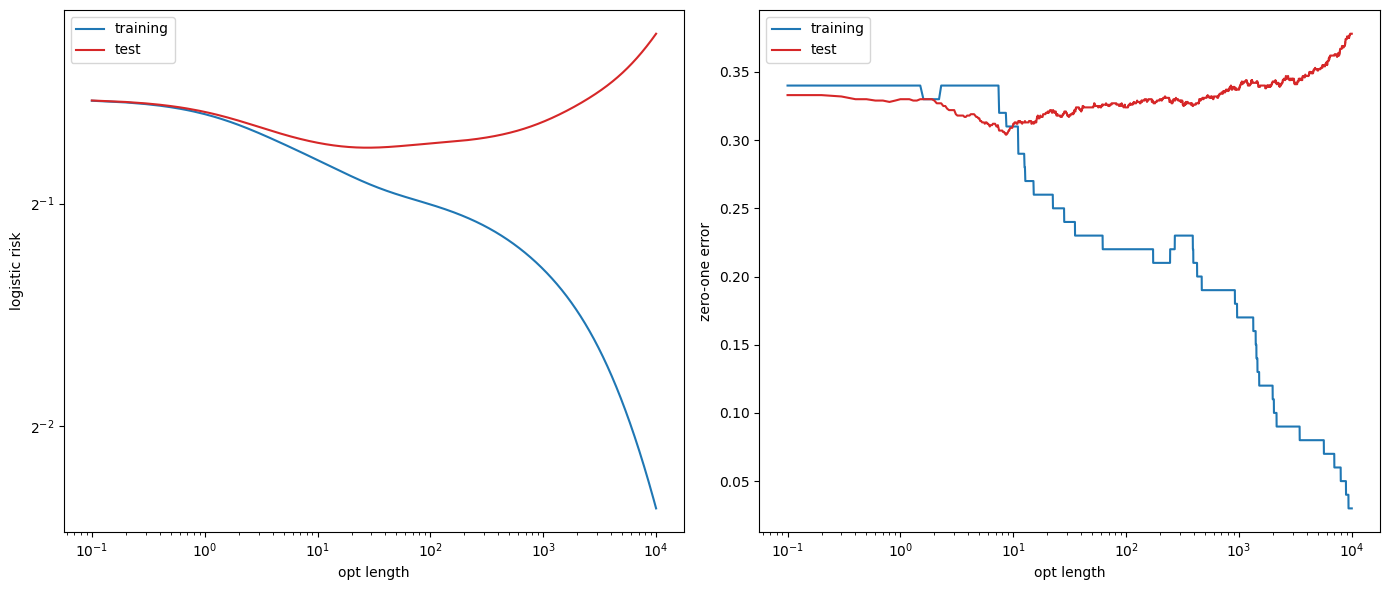

In [ ]:
n=100
m = 100

d=200

k=10

number_of_steps = int(1e5)

test_data_sample_size = 1000

# setting up w* -------
w_star = np.zeros(d)
w_star[:k]=1

# creating Sigma (basically a diagonal sigma) -----------
lambda_diag = np.arange(1, d+1, dtype=float) ** (-2)

eta = 0.1


# instantiating the class --------------------
logistic_class_instance = LogisticRegressionClass(n,d,random_seed=85)


X_data , y_data = logistic_class_instance.generate_data(
    d, n, w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

X_valid , y_valid = logistic_class_instance.generate_data(
    d, m, w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

X_test , y_test = logistic_class_instance.generate_data(
    d, test_data_sample_size, 
    w_star, use_lambda_diag= True, lambda_diag=lambda_diag
    )

result_trajectories = (
    logistic_class_instance.run_GD_for_t_steps
(
X_data, y_data, eta = eta, t_steps=number_of_steps, 
X_test= X_test, y_test=y_test,   
store_log_loss_traj_for_test=True,
store_zero_one_loss_traj_for_test=True
)
)



logistic_class_instance.plot(
        logistic_loss_training_trajectory = result_trajectories["log_loss_train"], 
            zero_one_loss_training_trajectory = result_trajectories["zero_one_train"], 
                 eta = eta,
                 logistic_loss_test_trajectory=result_trajectories["log_loss_test"],
                 zero_one_loss_test_trajectory=result_trajectories["zero_one_test"]
                             )


In [5]:
n=100
d=200

k=5 

w_star = np.zeros(d)
w_star[:k]=1
print (w_star)

[1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


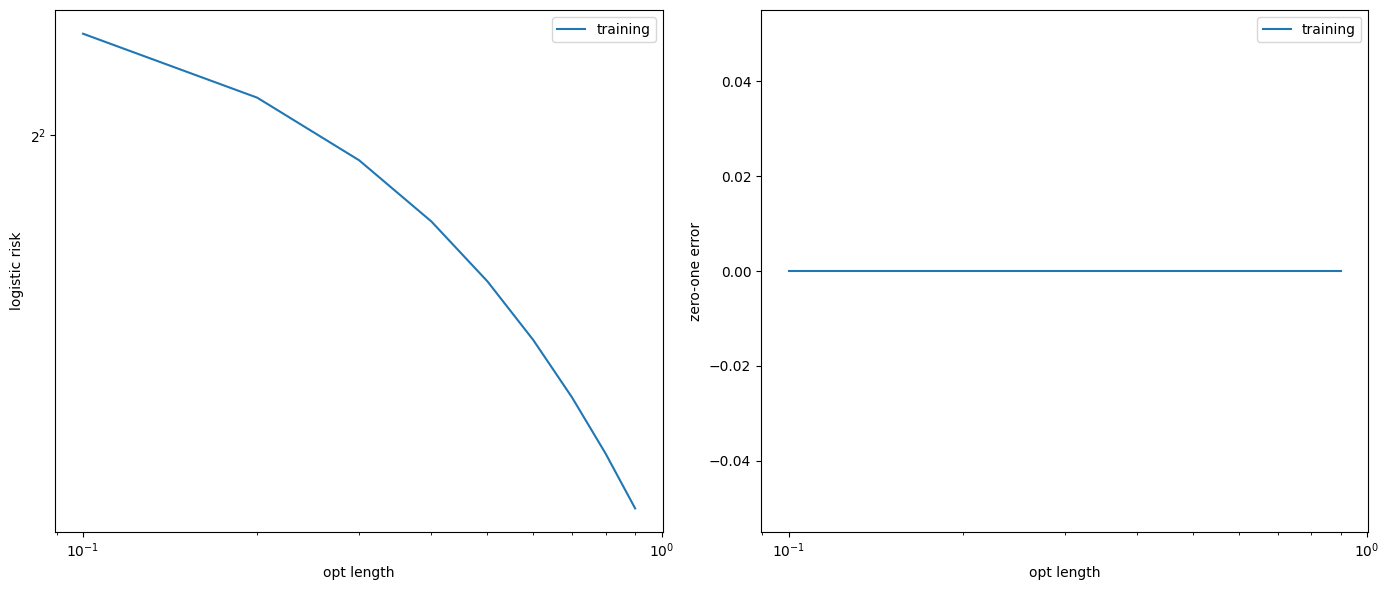

ValueError: operands could not be broadcast together with shapes (6,) (6,3) 

In [ ]:
logistic_class_isntance_2 = LogisticRegressionClass(random_seed=85)
